## Mohammad Bin Saeed Khattak
### i24-2503 DS 5A LAB 3

Task 1

Setup complete — 9994 rows loaded.


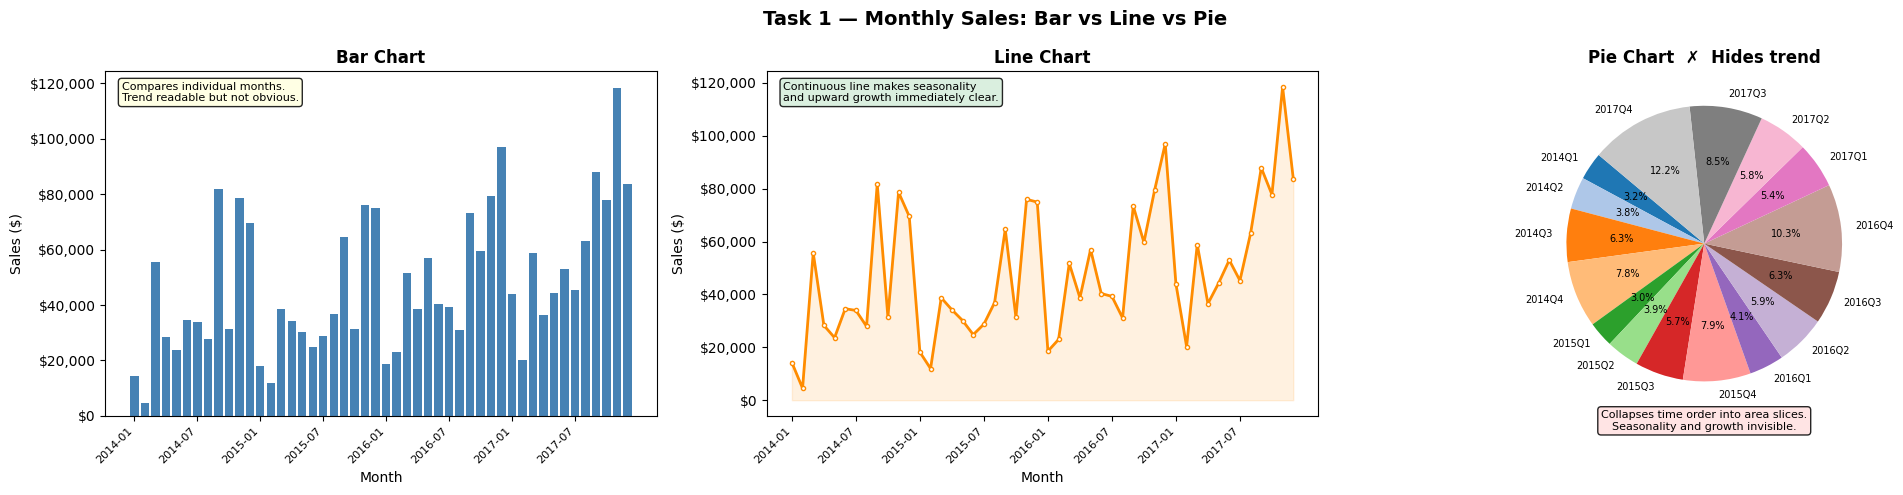

Line chart shows the trends best. Connected line shows time order visually, showing Q4 peaks more clearly. 
Pie chart hides trends worst. Merges all 48 periods into area slices with no visuals for time, hence growth is not visible.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
df['YQ']    = df['Order Date'].dt.to_period('Q').astype(str)

monthly_sales  = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
monthly_profit['Month'] = monthly_profit['Month'].astype(str)

top5_subcat  = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_cat   = df.groupby(['Region','Category'])['Sales'].sum().unstack(fill_value=0)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values('Profit')

fmt_dollar = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
fmt_M      = mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M')
fmt_K      = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
fmt_pct    = mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%')

TICK_IDX    = list(range(0, len(monthly_sales), 6))
TICK_LABELS = [monthly_sales['Month'].iloc[i] for i in TICK_IDX]

print('Setup complete —', len(df), 'rows loaded.')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Task 1 — Monthly Sales: Bar vs Line vs Pie', fontsize=14, fontweight='bold')

x = range(len(monthly_sales))
s = monthly_sales['Sales'].values

# bar
ax = axes[0]
ax.bar(x, s, color='steelblue')
ax.set_xticks(TICK_IDX)
ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('Bar Chart', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales ($)')
ax.text(0.03, 0.97, 'Compares individual months.\nTrend readable but not obvious.',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# line
ax = axes[1]
ax.plot(x, s, color='darkorange', linewidth=2, marker='o',
        markersize=3, markerfacecolor='white')
ax.fill_between(x, s, alpha=0.12, color='darkorange')
ax.set_xticks(TICK_IDX)
ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('Line Chart', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales ($)')
ax.text(0.03, 0.97, 'Continuous line makes seasonality\nand upward growth immediately clear.',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='#d4edda', alpha=0.85))

# pie
ax = axes[2]
quarterly = df.groupby('YQ')['Sales'].sum()
ax.pie(quarterly, labels=quarterly.index, autopct='%1.1f%%',
       startangle=140, textprops={'fontsize': 7},
       colors=sns.color_palette('tab20', len(quarterly)))
ax.set_title('Pie Chart  ✗  Hides trend', fontweight='bold')
ax.text(0, -1.35,
        'Collapses time order into area slices.\nSeasonality and growth invisible.',
        ha='center', fontsize=8,
        bbox=dict(boxstyle='round', fc='#ffe0e0', alpha=0.85))

plt.tight_layout()
plt.savefig('task1_chart_types.png', dpi=150, bbox_inches='tight')
plt.show()

print("Line chart shows the trends best. Connected line shows time order visually, showing Q4 peaks more clearly. ")
print("Pie chart hides trends worst. Merges all 48 periods into area slices with no visuals for time, hence growth is not visible.")

Task 2

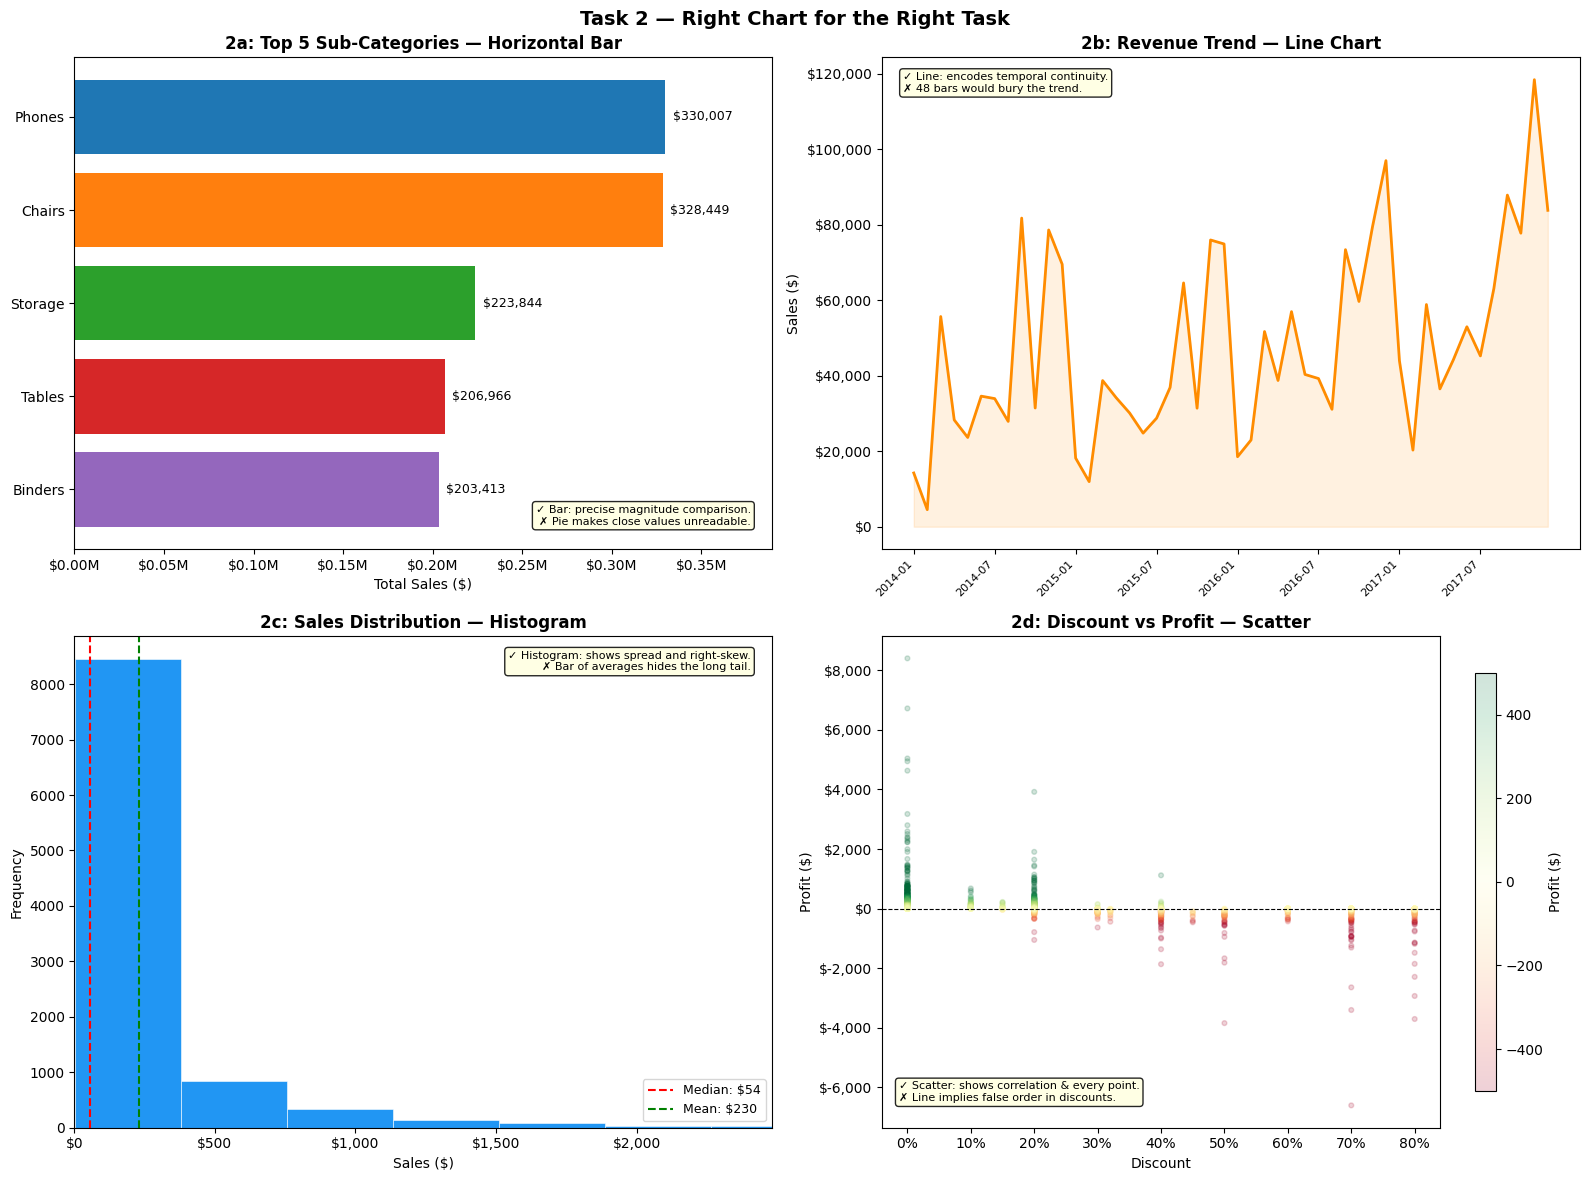

Horizontal bar chart is best for comparing discrete values across categorical data. Pie chart would be slightly unreadable due to closely valued magnitudes.
Line chart is best because 48 bars together would hide the trend
Histogram is best to show the skew (tail towards right)
Scatter plot shows its not continuous by considering every single plot point


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Task 2 — Right Chart for the Right Task', fontsize=14, fontweight='bold')

cat_colors = sns.color_palette('tab10', 5)

# Horizontal bar chart
ax = axes[0, 0]
bars = ax.barh(top5_subcat['Sub-Category'], top5_subcat['Sales'],
               color=cat_colors)
ax.invert_yaxis()
for bar, val in zip(bars, top5_subcat['Sales']):
    ax.text(val + 4000, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=9)
ax.set_xlim(0, top5_subcat['Sales'].max() * 1.18)
ax.xaxis.set_major_formatter(fmt_M)
ax.set_title('2a: Top 5 Sub-Categories — Horizontal Bar', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.text(0.97, 0.05,
        '✓ Bar: precise magnitude comparison.\n✗ Pie makes close values unreadable.',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# Line
ax = axes[0, 1]
x = range(len(monthly_sales))
ax.plot(x, monthly_sales['Sales'], color='darkorange', linewidth=2)
ax.fill_between(x, monthly_sales['Sales'], alpha=0.12, color='darkorange')
ax.set_xticks(TICK_IDX)
ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('2b: Revenue Trend — Line Chart', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.text(0.03, 0.97,
        '✓ Line: encodes temporal continuity.\n✗ 48 bars would bury the trend.',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# Histogram
ax = axes[1, 0]
ax.hist(df['Sales'], bins=60, color='#2196F3', edgecolor='white', linewidth=0.4)
ax.axvline(df['Sales'].median(), color='red',   linestyle='--', linewidth=1.5,
           label=f'Median: ${df["Sales"].median():.0f}')
ax.axvline(df['Sales'].mean(),   color='green', linestyle='--', linewidth=1.5,
           label=f'Mean: ${df["Sales"].mean():.0f}')
ax.set_xlim(0, df['Sales'].quantile(0.99))
ax.xaxis.set_major_formatter(fmt_dollar)
ax.set_title('2c: Sales Distribution — Histogram', fontweight='bold')
ax.set_xlabel('Sales ($)'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.text(0.97, 0.97,
        '✓ Histogram: shows spread and right-skew.\n✗ Bar of averages hides the long tail.',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# Scatter
ax = axes[1, 1]
sc = ax.scatter(df['Discount'], df['Profit'],
                alpha=0.18, s=12,
                c=df['Profit'], cmap='RdYlGn', vmin=-500, vmax=500)
plt.colorbar(sc, ax=ax, label='Profit ($)', shrink=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(fmt_pct)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('2d: Discount vs Profit — Scatter', fontweight='bold')
ax.set_xlabel('Discount'); ax.set_ylabel('Profit ($)')
ax.text(0.03, 0.05,
        '✓ Scatter: shows correlation & every point.\n✗ Line implies false order in discounts.',
        transform=ax.transAxes, va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

plt.tight_layout()
plt.savefig('task2_right_chart.png', dpi=150, bbox_inches='tight')
plt.show()


print("Horizontal bar chart is best for comparing discrete values across categorical data. Pie chart would be slightly unreadable due to closely valued magnitudes.")
print("Line chart is best because 48 bars together would hide the trend")
print("Histogram is best to show the skew (tail towards right)")
print("Scatter plot shows its not continuous by considering every single plot point")

Task 3

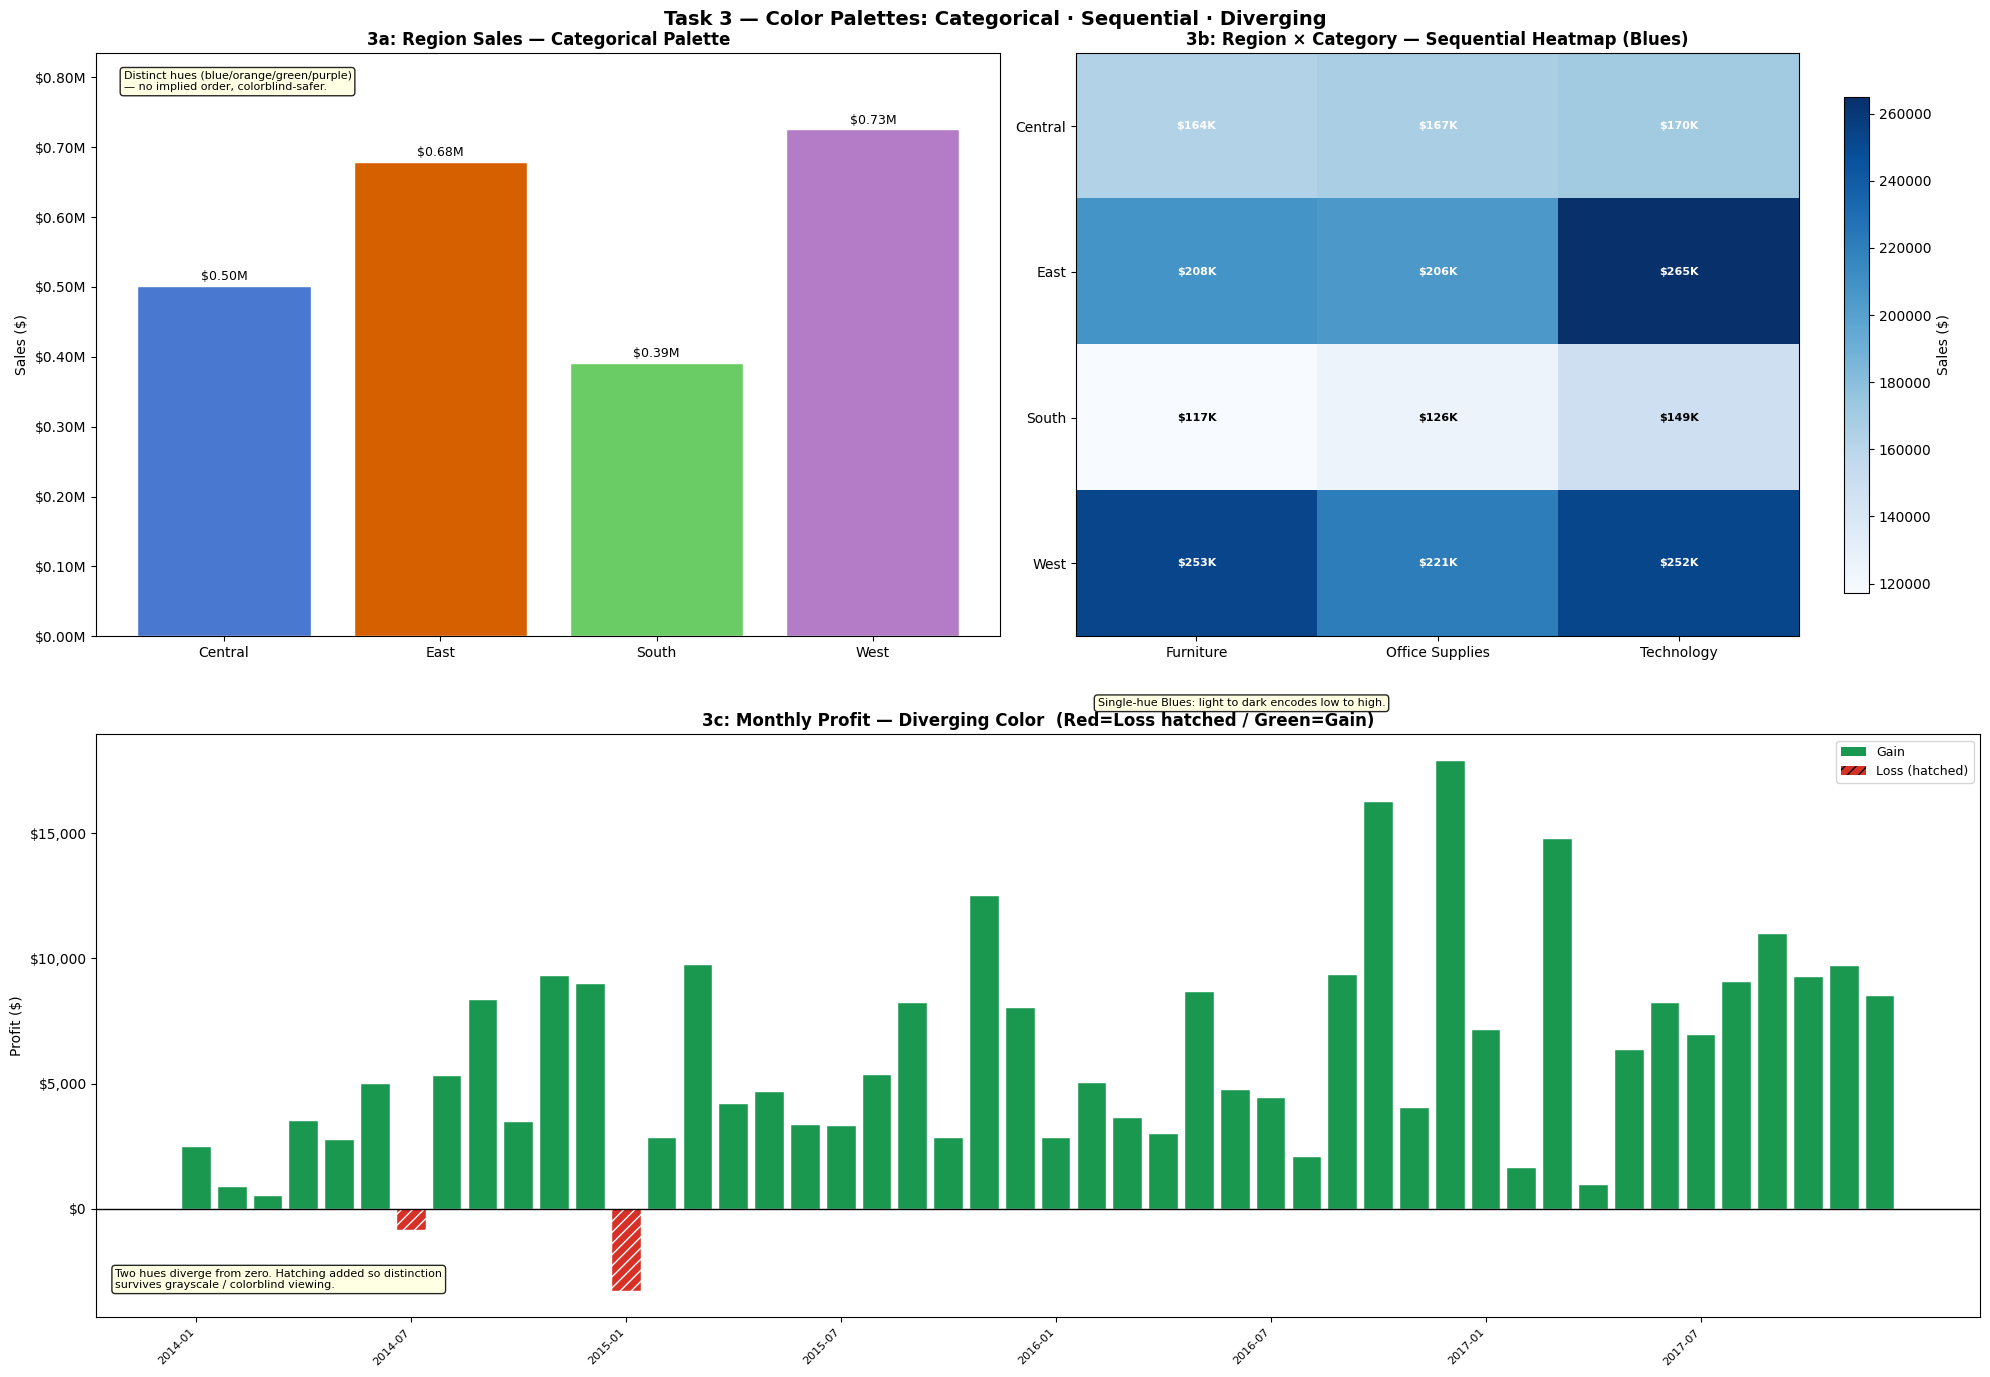

Categorical: four disctinct colors with no order. Safe for colorblind people
Sequentual, one single color varying from light to dark to show low maginitude to high magnitude. Not misleading
Diverging. Two colors diverging from zero, loss and gain are distinguishable even in grayscale.


In [9]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Task 3 — Color Palettes: Categorical · Sequential · Diverging',
             fontsize=14, fontweight='bold')

# 3a: categorical palette

ax1 = fig.add_subplot(2, 2, 1)
cat_pal = ['#4878CF', '#D65F00', '#6ACC65', '#B47CC7']
bars = ax1.bar(region_sales['Region'], region_sales['Sales'],
               color=cat_pal, edgecolor='white')
for bar, val in zip(bars, region_sales['Sales']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8000,
             f'${val/1e6:.2f}M', ha='center', fontsize=9)
ax1.set_ylim(0, region_sales['Sales'].max() * 1.15)
ax1.yaxis.set_major_formatter(fmt_M)
ax1.set_title('3a: Region Sales — Categorical Palette', fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.text(0.03, 0.97,
         'Distinct hues (blue/orange/green/purple)\n— no implied order, colorblind-safer.',
         transform=ax1.transAxes, va='top', fontsize=8,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# 3b: Sequential heatmap — region × category
ax2 = fig.add_subplot(2, 2, 2)
data_vals = region_cat.values
im = ax2.imshow(data_vals, cmap='Blues', aspect='auto')
ax2.set_xticks(range(len(region_cat.columns)))
ax2.set_xticklabels(region_cat.columns, fontsize=10)
ax2.set_yticks(range(len(region_cat.index)))
ax2.set_yticklabels(region_cat.index, fontsize=10)
ax2.set_title('3b: Region × Category — Sequential Heatmap (Blues)', fontweight='bold')
plt.colorbar(im, ax=ax2, label='Sales ($)', shrink=0.85)
thresh = data_vals.max() * 0.6
for i in range(data_vals.shape[0]):
    for j in range(data_vals.shape[1]):
        color = 'white' if data_vals[i, j] > thresh else 'black'
        ax2.text(j, i, f'${data_vals[i,j]/1e3:.0f}K',
                 ha='center', va='center', fontsize=8,
                 color=color, fontweight='bold')
ax2.text(0.03, -0.12,
         'Single-hue Blues: light to dark encodes low to high.',
         transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

# 3c: Diverging — monthly profit (crosses zero)
ax3 = fig.add_subplot(2, 1, 2)
profits = monthly_profit['Profit'].values
x = range(len(profits))
for i, p in enumerate(profits):
    color = '#d73027' if p < 0 else '#1a9850'
    hatch = '///' if p < 0 else ''
    ax3.bar(i, p, color=color, edgecolor='white', linewidth=0.3, hatch=hatch)
ax3.axhline(0, color='black', linewidth=1)
ax3.set_xticks(TICK_IDX)
ax3.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax3.yaxis.set_major_formatter(fmt_dollar)
ax3.set_title('3c: Monthly Profit — Diverging Color  (Red=Loss hatched / Green=Gain)',
              fontweight='bold')
ax3.set_ylabel('Profit ($)')

ax3.bar(0, 0, color='#1a9850', label='Gain')
ax3.bar(0, 0, color='#d73027', hatch='///', label='Loss (hatched)')
ax3.legend(fontsize=9)
ax3.text(0.01, 0.05,
         'Two hues diverge from zero. Hatching added so distinction\nsurvives grayscale / colorblind viewing.',
         transform=ax3.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))

plt.tight_layout()
plt.savefig('task3_palettes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Categorical: four disctinct colors with no order. Safe for colorblind people")
print("Sequentual, one single color varying from light to dark to show low maginitude to high magnitude. Not misleading")
print("Diverging. Two colors diverging from zero, loss and gain are distinguishable even in grayscale.")

Task 4

WCAG AA Contrast Audit (vs white #FFFFFF background)
  Color                   Hex           Ratio  Status
  ------------------------------------------------------
  3a Blue                 #4878CF       4.32:1  FAIL
  3a Orange               #D65F00       3.82:1  FAIL
  3a Green                #6ACC65       2.01:1  FAIL
  3a Purple               #B47CC7       3.16:1  FAIL
  3c Loss Red             #d73027       4.84:1  PASS
  3c Gain Green           #1a9850       3.72:1  FAIL

Note: fill colors below 4.5:1 still communicate via bar length;
      axis labels and data labels should always pass 4.5:1 against their background.


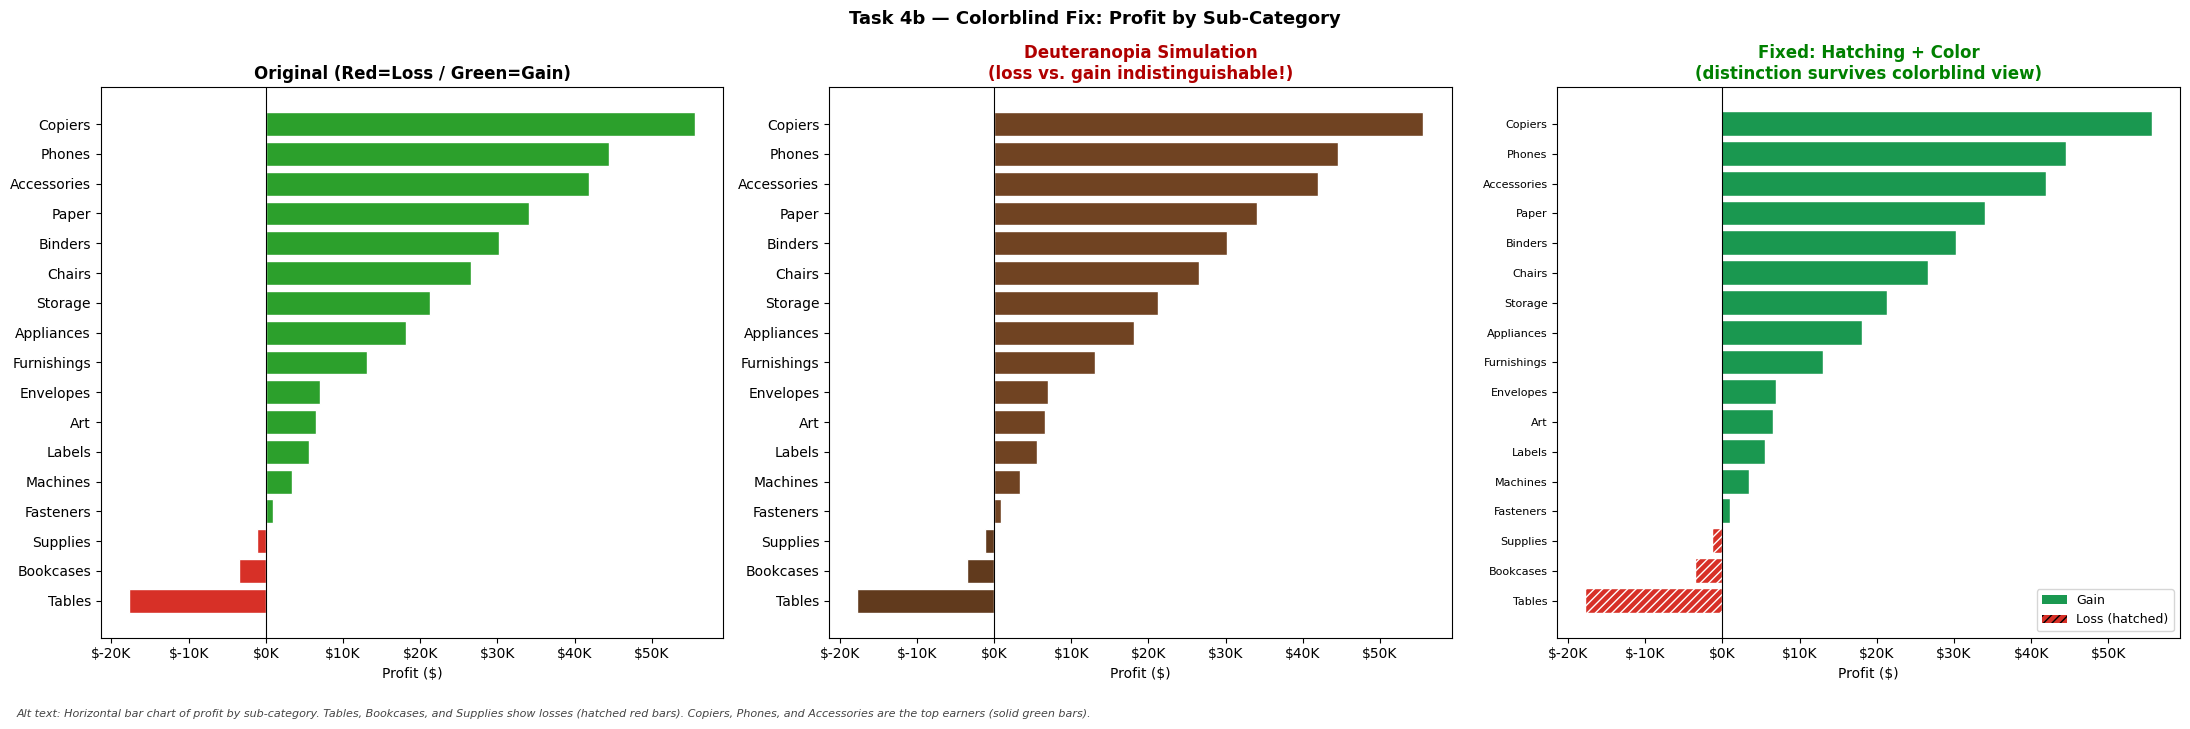


Chart alt text:
  "Horizontal bar chart of profit by sub-category. Tables, Bookcases, and Supplies show losses (hatched red bars). Copiers, Phones, and Accessories are the top earners (solid green bars)."


In [10]:
import matplotlib.colors as mcolors

def relative_luminance(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    def lin(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)

def wcag_contrast(hex1, hex2):
    L1, L2 = relative_luminance(hex1), relative_luminance(hex2)
    hi, lo = max(L1, L2), min(L1, L2)
    return (hi + 0.05) / (lo + 0.05)

BG = '#FFFFFF'
test_colors = {
    '3a Blue':        '#4878CF',
    '3a Orange':      '#D65F00',
    '3a Green':       '#6ACC65',
    '3a Purple':      '#B47CC7',
    '3c Loss Red':    '#d73027',
    '3c Gain Green':  '#1a9850',
}
AA = 4.5
print('WCAG AA Contrast Audit (vs white #FFFFFF background)')
print(f'  {"Color":<22}  {"Hex":<10}  {"Ratio":>7}  Status')
print('  ' + '-' * 54)
for name, hx in test_colors.items():
    r = wcag_contrast(hx, BG)
    st = 'PASS' if r >= AA else 'FAIL'
    print(f'  {name:<22}  {hx:<10}  {r:>6.2f}:1  {st}')

print()
print('Note: fill colors below 4.5:1 still communicate via bar length;')
print('      axis labels and data labels should always pass 4.5:1 against their background.')

def simulate_deuteranopia(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    L = 0.299*r + 0.587*g + 0.114*b
    return (L, L * 0.6, L * 0.3)

orig_colors = ['#d73027' if p < 0 else '#2ca02c' for p in subcat_profit['Profit']]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Task 4b — Colorblind Fix: Profit by Sub-Category', fontsize=13, fontweight='bold')


ax = axes[0]
ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'],
        color=orig_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(fmt_K)
ax.set_title('Original (Red=Loss / Green=Gain)', fontweight='bold')
ax.set_xlabel('Profit ($)')

ax = axes[1]
sim_colors = [simulate_deuteranopia(c) for c in orig_colors]
ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'],
        color=sim_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(fmt_K)
ax.set_title('Deuteranopia Simulation\n(loss vs. gain indistinguishable!)',
             fontweight='bold', color='#b00000')
ax.set_xlabel('Profit ($)')


ax = axes[2]
for i, (_, row) in enumerate(subcat_profit.iterrows()):
    color = '#d73027' if row['Profit'] < 0 else '#1a9850'
    hatch = '////' if row['Profit'] < 0 else ''
    ax.barh(i, row['Profit'], color=color, edgecolor='white',
            linewidth=0.3, hatch=hatch)
ax.set_yticks(range(len(subcat_profit)))
ax.set_yticklabels(subcat_profit['Sub-Category'], fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(fmt_K)
ax.set_title('Fixed: Hatching + Color\n(distinction survives colorblind view)',
             fontweight='bold', color='green')
ax.set_xlabel('Profit ($)')

ax.bar(0, 0, color='#1a9850', label='Gain')
ax.bar(0, 0, color='#d73027', hatch='////', label='Loss (hatched)')
ax.legend(fontsize=9, loc='lower right')

alt_text = ('Horizontal bar chart of profit by sub-category. '
            'Tables, Bookcases, and Supplies show losses (hatched red bars). '
            'Copiers, Phones, and Accessories are the top earners (solid green bars).')
fig.text(0.01, -0.03, f'Alt text: {alt_text}', fontsize=8, style='italic', color='#444')

plt.tight_layout()
plt.savefig('task4_accessibility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChart alt text:\n  "{alt_text}"')

Task 5

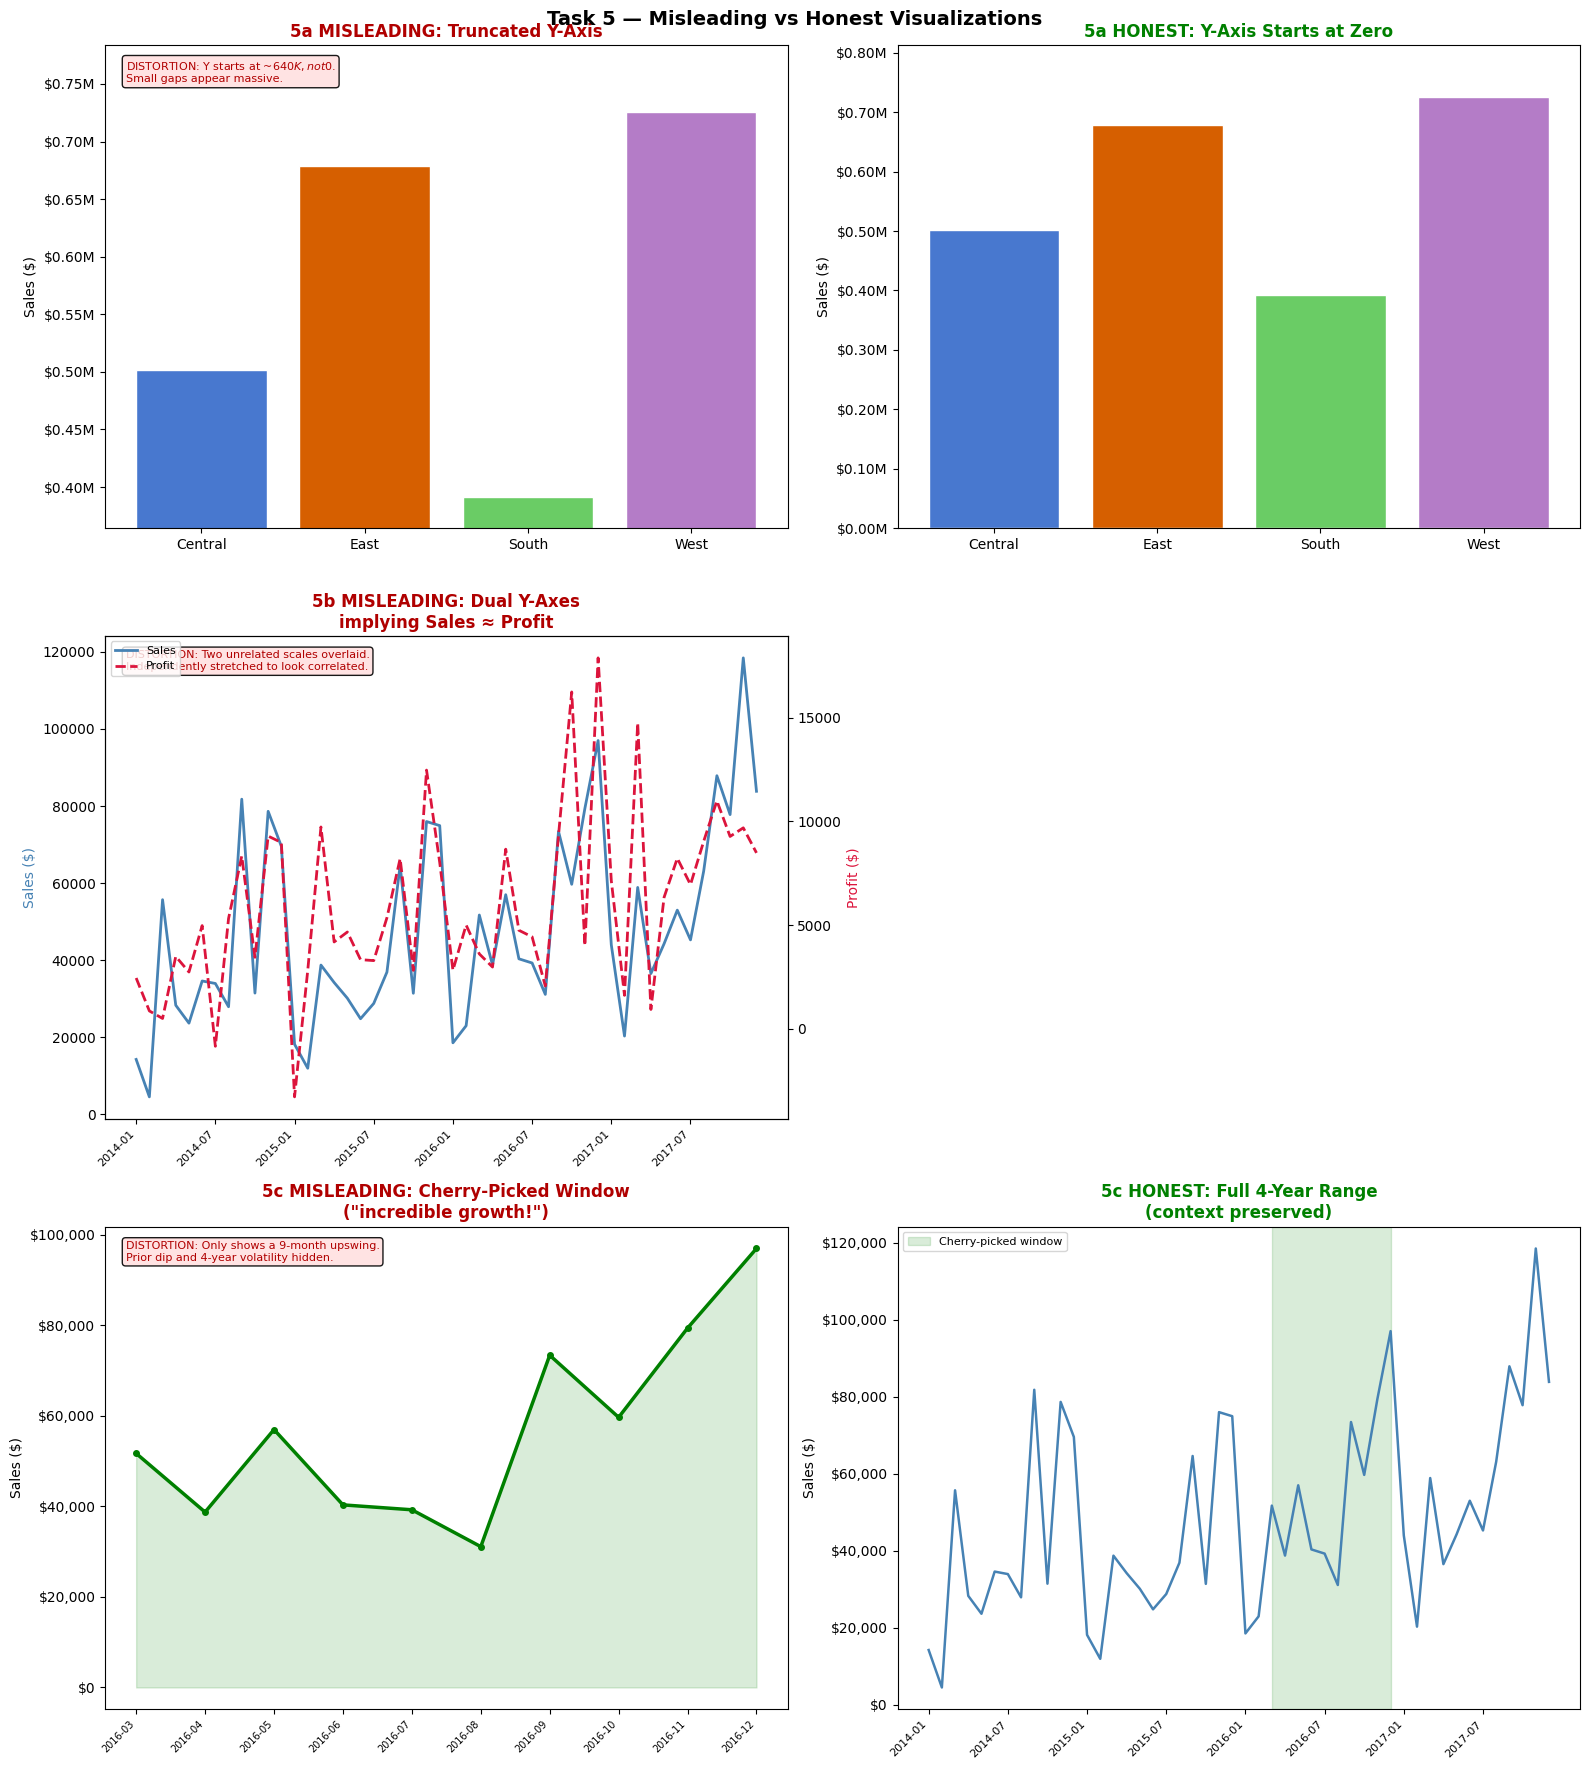

Truncated y axis: axis starts at 93% of the minimum value so the 7% absolute gap appears larger than it really is
Dual y axes: two scales independently stretched, showing a visual correltion that doesn't actually exist
cherry picked window: selected only 9 months to display only the steepest upswing.


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Task 5 — Misleading vs Honest Visualizations', fontsize=14, fontweight='bold')

months_arr  = monthly_sales['Month'].values
sales_arr   = monthly_sales['Sales'].values
profit_arr  = monthly_profit['Profit'].values
x           = range(len(months_arr))

cat_pal = ['#4878CF', '#D65F00', '#6ACC65', '#B47CC7']

ax = axes[0, 0]
ax.bar(region_sales['Region'], region_sales['Sales'], color=cat_pal, edgecolor='white')
ax.set_ylim(region_sales['Sales'].min() * 0.93, region_sales['Sales'].max() * 1.08)
ax.yaxis.set_major_formatter(fmt_M)
ax.set_title('5a MISLEADING: Truncated Y-Axis', fontweight='bold', color='#b00000')
ax.set_ylabel('Sales ($)')
ax.text(0.03, 0.97,
        'DISTORTION: Y starts at ~$640K, not $0.\nSmall gaps appear massive.',
        transform=ax.transAxes, va='top', fontsize=8, color='#b00000',
        bbox=dict(boxstyle='round', fc='#ffe0e0', alpha=0.9))

ax = axes[0, 1]
ax.bar(region_sales['Region'], region_sales['Sales'], color=cat_pal, edgecolor='white')
ax.set_ylim(0, region_sales['Sales'].max() * 1.12)
ax.yaxis.set_major_formatter(fmt_M)
ax.set_title('5a HONEST: Y-Axis Starts at Zero', fontweight='bold', color='green')
ax.set_ylabel('Sales ($)')

ax = axes[1, 0]
ax2 = ax.twinx()
l1, = ax.plot(x, sales_arr,  color='steelblue', linewidth=2, label='Sales')
l2, = ax2.plot(x, profit_arr, color='crimson', linewidth=2, linestyle='--', label='Profit')
ax.set_xticks(TICK_IDX)
ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_title('5b MISLEADING: Dual Y-Axes\nimplying Sales ≈ Profit', fontweight='bold', color='#b00000')
ax.set_ylabel('Sales ($)',  color='steelblue')
ax2.set_ylabel('Profit ($)', color='crimson')
ax.legend(handles=[l1, l2], loc='upper left', fontsize=8)
ax.text(0.03, 0.97,
        'DISTORTION: Two unrelated scales overlaid.\nIndependently stretched to look correlated.',
        transform=ax.transAxes, va='top', fontsize=8, color='#b00000',
        bbox=dict(boxstyle='round', fc='#ffe0e0', alpha=0.9))

ax = axes[1, 1]
inner1 = ax.inset_axes([0, 0.53, 1, 0.44])
inner2 = ax.inset_axes([0, 0.00, 1, 0.44])
ax.set_visible(False)
inner1.plot(x, sales_arr, color='steelblue', linewidth=1.5)
inner1.set_title('Sales', fontsize=9)
inner1.set_xticks([])
inner1.yaxis.set_major_formatter(fmt_K)
inner2.plot(x, profit_arr, color='crimson', linewidth=1.5)
inner2.set_title('Profit', fontsize=9)
inner2.set_xticks(TICK_IDX)
inner2.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=7)
inner2.yaxis.set_major_formatter(fmt_K)
ax.set_title('5b HONEST: Separate Panels', fontweight='bold', color='green')

ws, we = 26, 36
xc = range(we - ws)

ax = axes[2, 0]
ax.plot(xc, sales_arr[ws:we], color='green', linewidth=2.5,
        marker='o', markersize=4)
ax.fill_between(xc, sales_arr[ws:we], alpha=0.15, color='green')
ax.set_xticks(range(we - ws))
ax.set_xticklabels(months_arr[ws:we], rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('5c MISLEADING: Cherry-Picked Window\n("incredible growth!")',
             fontweight='bold', color='#b00000')
ax.set_ylabel('Sales ($)')
ax.text(0.03, 0.97,
        'DISTORTION: Only shows a 9-month upswing.\nPrior dip and 4-year volatility hidden.',
        transform=ax.transAxes, va='top', fontsize=8, color='#b00000',
        bbox=dict(boxstyle='round', fc='#ffe0e0', alpha=0.9))

ax = axes[2, 1]
ax.plot(x, sales_arr, color='steelblue', linewidth=1.8)
ax.axvspan(ws, we - 1, alpha=0.15, color='green', label='Cherry-picked window')
ax.set_xticks(TICK_IDX)
ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('5c HONEST: Full 4-Year Range\n(context preserved)', fontweight='bold', color='green')
ax.set_ylabel('Sales ($)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('task5_misleading.png', dpi=150, bbox_inches='tight')
plt.show()

print("Truncated y axis: axis starts at 93% of the minimum value so the 7% absolute gap appears larger than it really is")
print("Dual y axes: two scales independently stretched, showing a visual correltion that doesn't actually exist")
print("cherry picked window: selected only 9 months to display only the steepest upswing.")

Task 6

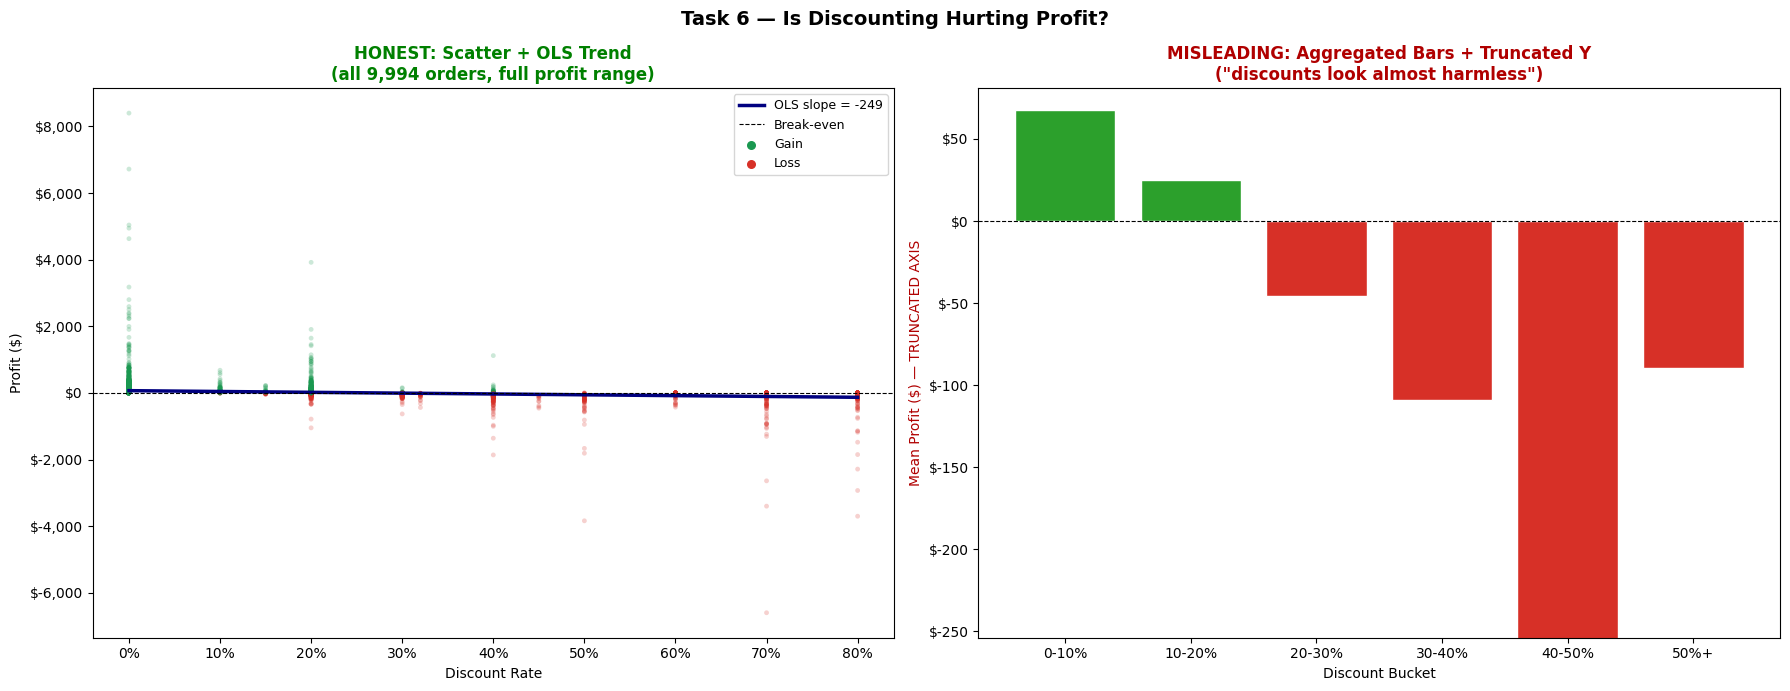

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Task 6 — Is Discounting Hurting Profit?', fontsize=14, fontweight='bold')

coefs = np.polyfit(df['Discount'], df['Profit'], 1)
x_line = np.linspace(0, df['Discount'].max(), 200)

ax = axes[0]
dot_colors = ['#d73027' if p < 0 else '#1a9850' for p in df['Profit']]
ax.scatter(df['Discount'], df['Profit'],
           c=dot_colors, alpha=0.22, s=12, edgecolors='none')
ax.plot(x_line, np.polyval(coefs, x_line),
        color='navy', linewidth=2.5, label=f'OLS slope = {coefs[0]:.0f}')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Break-even')
ax.xaxis.set_major_formatter(fmt_pct)
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('HONEST: Scatter + OLS Trend\n(all 9,994 orders, full profit range)',
             fontweight='bold', color='green')
ax.set_xlabel('Discount Rate'); ax.set_ylabel('Profit ($)')

ax.scatter([], [], c='#1a9850', s=30, label='Gain')
ax.scatter([], [], c='#d73027', s=30, label='Loss')
ax.legend(fontsize=9)


ax = axes[1]
df['Discount_Bucket'] = pd.cut(
    df['Discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
    labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50%+'],
    include_lowest=True
)
mean_profit = (df.groupby('Discount_Bucket', observed=True)['Profit']
                 .mean().reset_index())
bar_cols = ['#2ca02c' if v >= 0 else '#d73027' for v in mean_profit['Profit']]
ax.bar(mean_profit['Discount_Bucket'].astype(str), mean_profit['Profit'],
       color=bar_cols, edgecolor='white')
ax.set_ylim(mean_profit['Profit'].min() * 0.85, mean_profit['Profit'].max() * 1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_title('MISLEADING: Aggregated Bars + Truncated Y\n("discounts look almost harmless")',
             fontweight='bold', color='#b00000')
ax.set_xlabel('Discount Bucket')
ax.set_ylabel('Mean Profit ($) — TRUNCATED AXIS', color='#b00000')


plt.tight_layout()
plt.savefig('task6_honest_vs_misleading.png', dpi=150, bbox_inches='tight')
plt.show()
